In [1]:
# Libraries used in the whole project
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Resume.csv")
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

df[['Resume_str', 'cleaned_resume']].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associatehr administ...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [4]:
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_resume'] = df['cleaned_resume'].apply(remove_stopwords)

In [5]:
df['cleaned_resume'].head()

0    hr administratormarketing associatehr administ...
1    hr specialist us hr operations summary versati...
2    hr director summary years experience recruitin...
3    hr specialist summary dedicated driven dynamic...
4    hr manager skill highlights hr skills hr depar...
Name: cleaned_resume, dtype: object

In [6]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [7]:
df[df['Category'] == 'INFORMATION-TECHNOLOGY'].head()

,ID,Resume_str,Resume_html,Category,cleaned_resume
217,36856210,INFORMATION TECHNOLOGY Summar...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY,information technology summary dedicated infor...
218,21780877,INFORMATION TECHNOLOGY SPECIALIST\tGS...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY,information technology specialistgs experience...
219,33241454,INFORMATION TECHNOLOGY SUPERVISOR ...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY,information technology supervisor summary seek...
220,25990239,INFORMATION TECHNOLOGY INSTRUCTOR ...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY,information technology instructor summary seve...
221,16899268,INFORMATION TECHNOLOGY MANAGER/ANALYS...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY,information technology manageranalyst professi...


In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),   # bigrams added
    min_df=2,            # ignore rare words
    max_df=0.9           # ignore too common words
)

X = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category']

In [9]:
# Checking what keywords target to Apparel field
feature_names = tfidf.get_feature_names_out()

def get_top_keywords(category, n=10):
    # filter data for category
    subset = df[df['Category'] == category]
    
    # transform text
    X_cat = tfidf.transform(subset['cleaned_resume'])
    
    # average scores
    mean_scores = np.mean(X_cat.toarray(), axis=0)
    
    # top indices
    top_indices = mean_scores.argsort()[-n:][::-1]
    
    # top words
    return [feature_names[i] for i in top_indices]

get_top_keywords("APPAREL", 10)

['sales',
 'store',
 'customer',
 'apparel',
 'name city',
 'product',
 'merchandising',
 'merchandise',
 'inventory',
 'customers']

In [10]:
# Checking what keywords target to Information Technology field
feature_names = tfidf.get_feature_names_out()

def get_top_keywords(category, n=10):
    # filter data for category
    subset = df[df['Category'] == category]
    
    # transform text
    X_cat = tfidf.transform(subset['cleaned_resume'])
    
    # average scores
    mean_scores = np.mean(X_cat.toarray(), axis=0)
    
    # top indices
    top_indices = mean_scores.argsort()[-n:][::-1]
    
    # top words
    return [feature_names[i] for i in top_indices]

get_top_keywords("INFORMATION-TECHNOLOGY", 10)

['network',
 'technology',
 'information technology',
 'information',
 'systems',
 'support',
 'server',
 'security',
 'software',
 'management']

In [11]:
# Checking what keywords target to Automobile field
feature_names = tfidf.get_feature_names_out()

def get_top_keywords(category, n=10):
    # filter data for category
    subset = df[df['Category'] == category]
    
    # transform text
    X_cat = tfidf.transform(subset['cleaned_resume'])
    
    # average scores
    mean_scores = np.mean(X_cat.toarray(), axis=0)
    
    # top indices
    top_indices = mean_scores.argsort()[-n:][::-1]
    
    # top words
    return [feature_names[i] for i in top_indices]

get_top_keywords("AUTOMOBILE", 10)

['customer',
 'claims',
 'service',
 'customer service',
 'name city',
 'management',
 'sales',
 'automobile',
 'data',
 'call']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6619718309859155


In [14]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.83      0.86      0.85        29
              ADVOCATE       0.59      0.57      0.58        30
           AGRICULTURE       0.12      0.12      0.12         8
               APPAREL       0.47      0.40      0.43        20
                  ARTS       0.25      0.22      0.24        18
            AUTOMOBILE       0.25      0.33      0.29         6
              AVIATION       0.82      0.86      0.84        21
               BANKING       0.71      0.65      0.68        23
                   BPO       0.20      0.50      0.29         2
  BUSINESS-DEVELOPMENT       0.95      0.74      0.83        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.90      0.79      0.84        34
            CONSULTANT       0.55      0.30      0.39        20
              DESIGNER       0.75      0.79      0.77        19
         DIGITAL-MEDIA       0.81      

The model achieves an overall accuracy of ~66%, with better performance on well-represented categories. Lower macro scores indicate challenges in minority classes due to class imbalance and overlapping vocabulary. This highlights the importance of balanced datasets and richer feature representations in text classification tasks.

In [15]:
cm = confusion_matrix(y_test, y_pred)

In [16]:
pd.DataFrame(cm)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,25,0,0,0,0,0,0,0,0,0,...,0,0,3,0,1,0,0,0,0,0
1,0,17,0,0,1,2,0,0,0,0,...,1,0,0,0,6,1,1,0,1,0
2,1,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,1,2
3,0,0,1,8,2,1,1,1,0,0,...,0,1,0,0,0,0,0,0,4,0
4,0,0,0,1,4,0,0,0,1,0,...,0,1,1,0,0,2,1,0,1,3
5,0,2,1,1,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,18,0,0,0,...,0,2,0,0,0,0,1,0,0,0
7,1,0,2,0,1,0,0,15,1,0,...,0,0,2,0,0,0,0,0,0,0
8,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,1,0,0,1,1,20,...,1,0,0,0,1,1,0,0,1,0


#### Model Insights
- Model performance improved after applying n-grams and class balancing
- Categories with fewer samples (e.g., Agriculture, Automobile) show lower performance due to data imbalance
- Logistic Regression performs well for text classification with TF-IDF features
- Similar job roles show overlap, causing misclassification (e.g., Business, Sales, Consultant)

In [17]:
import pickle

pickle.dump(model, open("resume_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

In [18]:
sample_text = "Data analyst with Python, SQL, machine learning"

cleaned = clean_text(sample_text)
vector = tfidf.transform([cleaned])

prediction = model.predict(vector)

In [19]:
proba = model.predict_proba(vector)
confidence = max(proba[0])

print("Predicted Category:", prediction[0])
print("Confidence:", round(confidence, 2))

Predicted Category: AUTOMOBILE
Confidence: 0.1


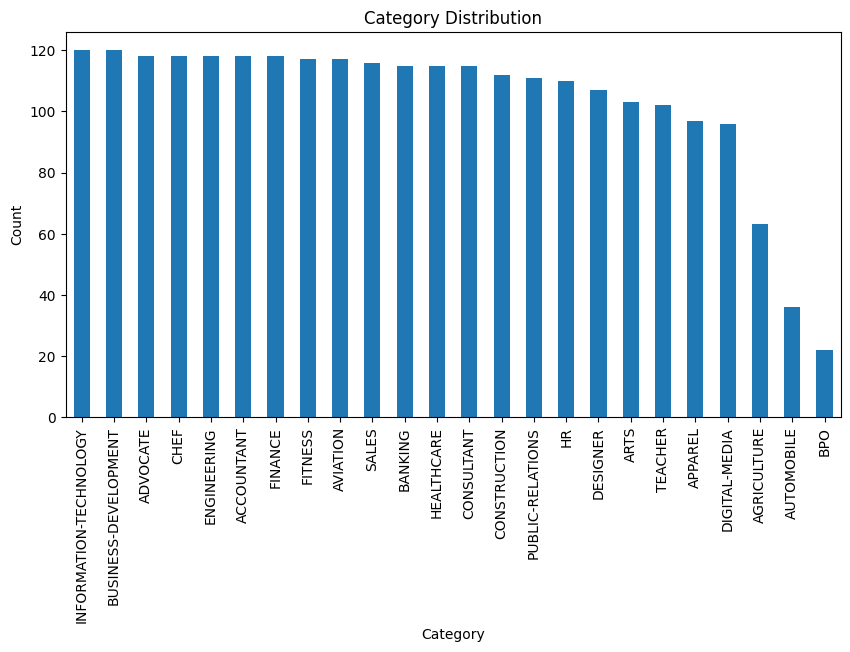

In [20]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

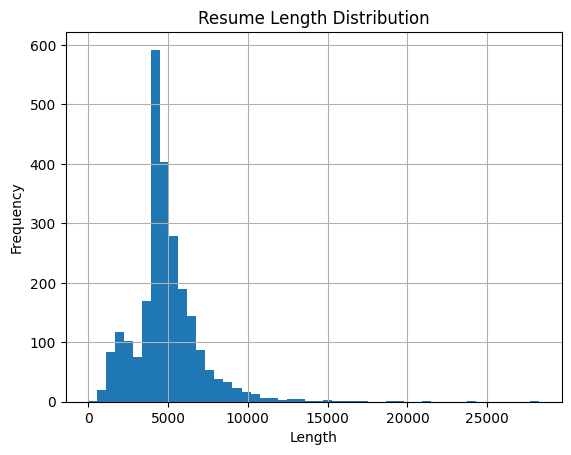

In [21]:
df['resume_length'] = df['cleaned_resume'].apply(len)

df['resume_length'].hist(bins=50)
plt.title("Resume Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

#### Key Observations
- The dataset shows moderate class imbalance, with certain categories having significantly fewer samples.
- Resume text lengths follow a right-skewed distribution, with most resumes falling within a consistent range but some outliers present.
- Categories with fewer samples and overlapping vocabulary tend to have lower model performance.
- TF-IDF based models rely heavily on word frequency, which can lead to misclassification when domains share similar terminology.

## Recommendations

- Address class imbalance by collecting more data for underrepresented categories (e.g., BPO, Agriculture, Automobile) or applying resampling techniques.

- Improve feature representation by using advanced NLP techniques such as Word2Vec, GloVe, or transformer-based models like BERT to capture semantic meaning.

- Refine or merge overlapping categories (e.g., Engineering and Information Technology) to reduce ambiguity and improve classification performance.

- Enhance text preprocessing by incorporating techniques such as lemmatization and domain-specific keyword extraction.

- Introduce a confidence threshold to flag low-confidence predictions and avoid misleading outputs.

- Deploy the model as a web application (e.g., using Streamlit or Flask) to make it usable in real-world scenarios.